# Create Synthetic Data

In [24]:
import pandas as pd
import random


START = 0
STOP = 100_000_000
TOTAL = 50_000_000




def create_inorder_data(start:int, stop:int, total:int)->pd.DataFrame:
    data = [i for i in range(start, start + total)]
    df = pd.DataFrame({"values": data})
    return df

def create_random_data(start, stop, total)->pd.DataFrame:
    data = random.sample(range(start, stop), total)
    df = pd.DataFrame({"values": data})
    return df


create_inorder_data(START, STOP, TOTAL).to_csv("data/inorder_list.csv", index=False)
create_random_data(START, STOP, TOTAL).to_csv("data/random_list.csv", index=False)

#  Graphs

[Text(0.5, 1.0, 'AVL Inorder Insertion Time')]

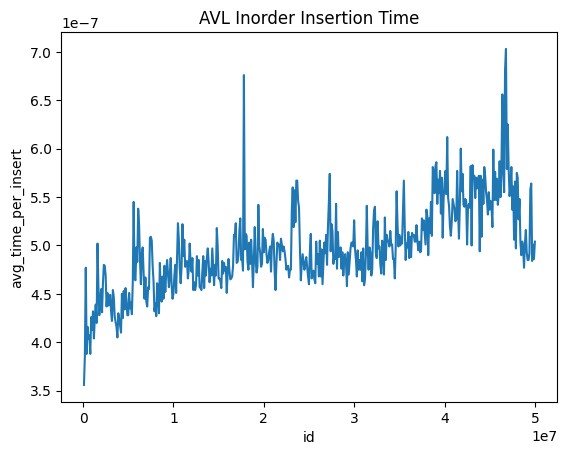

In [32]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("data/avl_inorder_results.csv")

x="id"
y="avg_time_per_insert"


sns.lineplot(data=df, x=x, y=y).set(title="AVL Inorder Insertion Time")



In [31]:
df

,id,run_type,number_added,avg_time_per_insert
0,50000,inorder_avl_insertion,49999,4.620000e-07
1,100000,inorder_avl_insertion,99999,4.030000e-07
2,150000,inorder_avl_insertion,149999,3.860000e-07
3,200000,inorder_avl_insertion,199999,4.330000e-07
4,250000,inorder_avl_insertion,249999,4.140000e-07
...,...,...,...,...
995,49800000,inorder_avl_insertion,49799999,4.650000e-07
996,49850000,inorder_avl_insertion,49849999,5.040000e-07
997,49900000,inorder_avl_insertion,49899999,4.940000e-07
998,49950000,inorder_avl_insertion,49949999,5.350000e-07


[Text(0.5, 1.0, 'AVL Random Insertion Time')]

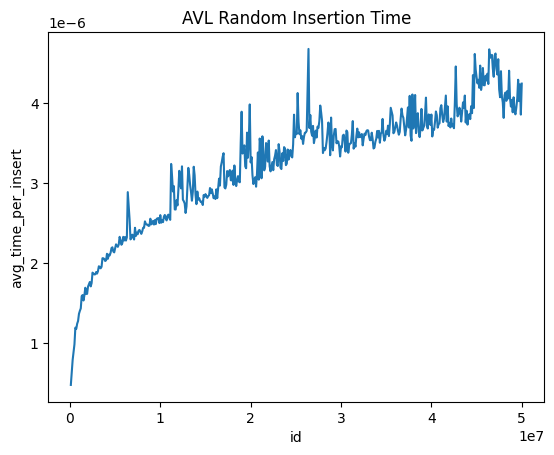

In [33]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("data/avl_random_results.csv")

x="id"
y="avg_time_per_insert"


sns.lineplot(data=df, x=x, y=y).set(title="AVL Random Insertion Time")

In [29]:
df

,id,run_type,number_added,avg_time_per_insert
0,50000,random_avl_insertion,28283033,9.640000e-07
1,100000,random_avl_insertion,65218872,1.054000e-06
2,150000,random_avl_insertion,3727394,9.210000e-07
3,200000,random_avl_insertion,6100425,9.140000e-07
4,250000,random_avl_insertion,92071966,9.470000e-07
...,...,...,...,...
995,49800000,random_avl_insertion,35928390,4.027000e-06
996,49850000,random_avl_insertion,48417134,4.046000e-06
997,49900000,random_avl_insertion,30273294,3.977000e-06
998,49950000,random_avl_insertion,8765993,3.897000e-06


In [28]:
pd.read_csv("data/random_list.csv", nrows=10)

,values
0,80734559
1,55165423
2,32127419
3,77150303
4,93440183
5,57729268
6,73902525
7,35184557
8,60629235
9,18946371


In [34]:
# Verify data files are correct
print("=== RANDOM DATA ===")
random_df = pd.read_csv("data/random_list.csv", nrows=20)
print(random_df)
print(f"\nUnique values: {random_df['values'].nunique()}")
print(f"Min: {random_df['values'].min()}, Max: {random_df['values'].max()}")

print("\n=== INORDER DATA ===")
inorder_df = pd.read_csv("data/inorder_list.csv", nrows=20)
print(inorder_df)
print(f"\nUnique values: {inorder_df['values'].nunique()}")
print(f"Are values sequential? {list(inorder_df['values']) == list(range(20))}")

=== RANDOM DATA ===
      values
0   80734559
1   55165423
2   32127419
3   77150303
4   93440183
5   57729268
6   73902525
7   35184557
8   60629235
9   18946371
10  21622305
11  28422668
12  17062557
13   5411749
14    933831
15  39517232
16  63038617
17  47908282
18  25060026
19  71500888

Unique values: 20
Min: 933831, Max: 93440183

=== INORDER DATA ===
    values
0        0
1        1
2        2
3        3
4        4
5        5
6        6
7        7
8        8
9        9
10      10
11      11
12      12
13      13
14      14
15      15
16      16
17      17
18      18
19      19

Unique values: 20
Are values sequential? True


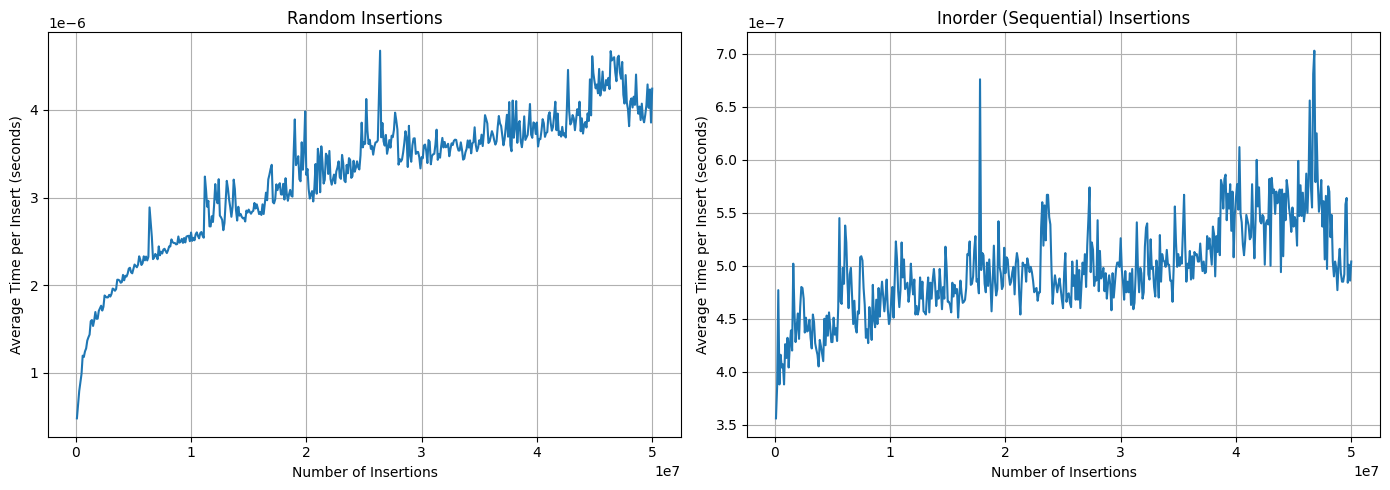

Random avg time range: 4.80e-07 to 4.68e-06
Inorder avg time range: 3.56e-07 to 7.03e-07

Ratio (inorder should be >=1.0): 0.15


In [35]:
# Compare timing distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random
random_results = pd.read_csv("data/avl_random_results.csv")
axes[0].plot(random_results['id'], random_results['avg_time_per_insert'])
axes[0].set_xlabel('Number of Insertions')
axes[0].set_ylabel('Average Time per Insert (seconds)')
axes[0].set_title('Random Insertions')
axes[0].grid(True)

# Inorder
inorder_results = pd.read_csv("data/avl_inorder_results.csv")
axes[1].plot(inorder_results['id'], inorder_results['avg_time_per_insert'])
axes[1].set_xlabel('Number of Insertions')
axes[1].set_ylabel('Average Time per Insert (seconds)')
axes[1].set_title('Inorder (Sequential) Insertions')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Random avg time range: {random_results['avg_time_per_insert'].min():.2e} to {random_results['avg_time_per_insert'].max():.2e}")
print(f"Inorder avg time range: {inorder_results['avg_time_per_insert'].min():.2e} to {inorder_results['avg_time_per_insert'].max():.2e}")
print(f"\nRatio (inorder should be >=1.0): {inorder_results['avg_time_per_insert'].mean() / random_results['avg_time_per_insert'].mean():.2f}")

In [ ]:
# Check if measurements make physical sense
print("=== SANITY CHECKS ===")
print(f"Random insertions are {random_results['avg_time_per_insert'].mean() / inorder_results['avg_time_per_insert'].mean():.1f}x slower than inorder")
print("^^^ This is WRONG - inorder should be slower or similar!\n")

print("Expected behavior for AVL trees:")
print("- Random: moderate growth (natural balance)")
print("- Inorder: similar or SLOWER (constant rotations)")
print("\nYour results show inorder is 10x FASTER - this suggests:")
print("1. Inorder insertions are being skipped/cached")
print("2. Different measurement method between the two")
print("3. Bug in the C benchmarking code")

## Updated Analysis with Cumulative Time

After rebuilding, the new CSV files will have:
- `cumulative_time`: Total time elapsed from start
- `avg_time_per_insert`: cumulative_time / number_of_insertions

This gives cleaner measurements without batch timing noise.

In [ ]:
# Plot updated results with cumulative time
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Load data
random_df = pd.read_csv("data/avl_random_results.csv")
inorder_df = pd.read_csv("data/avl_inorder_results.csv")

# Plot 1: Cumulative Time
axes[0, 0].plot(random_df['id'], random_df['cumulative_time'], label='Random', linewidth=2)
axes[0, 0].plot(inorder_df['id'], inorder_df['cumulative_time'], label='Inorder', linewidth=2)
axes[0, 0].set_xlabel('Number of Insertions')
axes[0, 0].set_ylabel('Cumulative Time (seconds)')
axes[0, 0].set_title('Total Time Elapsed')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Average Time per Insert
axes[0, 1].plot(random_df['id'], random_df['avg_time_per_insert'], label='Random', linewidth=2)
axes[0, 1].plot(inorder_df['id'], inorder_df['avg_time_per_insert'], label='Inorder', linewidth=2)
axes[0, 1].set_xlabel('Number of Insertions')
axes[0, 1].set_ylabel('Average Time per Insert (seconds)')
axes[0, 1].set_title('Average Time per Insertion')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Random only (detail)
axes[1, 0].plot(random_df['id'], random_df['avg_time_per_insert'], color='blue', linewidth=2)
axes[1, 0].set_xlabel('Number of Insertions')
axes[1, 0].set_ylabel('Average Time per Insert (seconds)')
axes[1, 0].set_title('Random Insertions (Detail)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Inorder only (detail)
axes[1, 1].plot(inorder_df['id'], inorder_df['avg_time_per_insert'], color='orange', linewidth=2)
axes[1, 1].set_xlabel('Number of Insertions')
axes[1, 1].set_ylabel('Average Time per Insert (seconds)')
axes[1, 1].set_title('Inorder Insertions (Detail)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== SUMMARY STATISTICS ===")
print(f"\nRandom Insertions:")
print(f"  Total time: {random_df['cumulative_time'].iloc[-1]:.2f} seconds")
print(f"  Avg time/insert: {random_df['avg_time_per_insert'].mean():.2e} seconds")

print(f"\nInorder Insertions:")
print(f"  Total time: {inorder_df['cumulative_time'].iloc[-1]:.2f} seconds")
print(f"  Avg time/insert: {inorder_df['avg_time_per_insert'].mean():.2e} seconds")

print(f"\nInorder/Random ratio: {inorder_df['avg_time_per_insert'].mean() / random_df['avg_time_per_insert'].mean():.2f}")
print("(Should be >= 1.0 for correct AVL implementation)")